# Stochastic evolution of a colony of B cells

In [22]:
import matplotlib.pyplot as plt
from __future__ import annotations
import numpy as np
from numpy.random import default_rng
import pandas as pd

In [23]:
"""
Germinal‑centre B‑cell maturation with multiple antigens
========================================================

• State of each cycling B‑cell: h ∈ ℝ^{N_h} (residue binding‑energy vector)
• Antigens:            S_mat ∈ {‑1, +1}^{N_h × n_A}
                       ε_v(h) = Σ_i s_{iv} h_i    for every antigen v
• One round:           duplication → SHM → Ag‑gate → T‑gate → differentiation
• Output:              `history[step]` is a NumPy array of shape
                       (n_cells_alive_that_step, N_h) with the h‑vectors

The implementation below follows exactly the gates used in your FP solver.
"""



mu=0.001*3*40
p_sil=0.5*(mu)+(1-mu)
p_let=0.3*(mu)
p_aa=0.2*(mu)
E_a=np.log(40)                       
T=140
kBT=1                       # thermal factor
N_i=2500  
N_max=2500 
mu_i=0.0 
sigma_i=0.001
p_diff=0.10
c=170# 800, 1120, 920, 510

# global parameters (use existing values or define defaults)

# -------------------------- helper functions ---------------------------
def energies(pop: np.ndarray, S_mat: np.ndarray) -> np.ndarray:
    """
    Compute energies for every cell and every antigen.

    Parameters
    ----------
    pop   : (N_cells, N_h) ndarray
    S_mat : (N_h, n_A)     ndarray

    Returns
    -------
    eps : (N_cells, n_A) ndarray   with eps[c, v] = ε_v(h_c)
    """
    return pop @ S_mat                     # broadcasting handles dot‑product

def P_Ag(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    Antigen‑binding survival gate   P_Ag(h)

    eps   : (N_cells, n_A) energies
    C_vec : (n_A,)        antigen concentrations at current round
    """
    exp_term   = np.exp((eps - E_a) / kBT)         # same as FP code
    numer      = (exp_term * C_vec).sum(axis=1)    # Σ_v C_v e^{(ε_v - E_a)/kT}
    return numer / (1.0 + numer)

def P_T(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    T‑cell‑help survival gate   P_T(h | pop)

    eps   : (N_cells, n_A) energies *after* Ag selection
    """
    C_tot      = C_vec.sum()
    eE         = np.exp(eps / kBT)                 # e^{ε_v/kT}
    Phi        = (eE * C_vec).sum(axis=1)          # Σ_v C_v e^{ε_v/kT}
    Phi_bar    = Phi.mean()                       # ⟨Φ⟩_pop
    return Phi / (Phi + Phi_bar / C_tot)

# --

## Trying to track mutations

In [24]:
def gc_round(pop: np.ndarray,
             S_mat: np.ndarray,
             C_vec: np.ndarray,
             rng: np.random.Generator,
             mu_M: np.ndarray,
             sigma_M: np.ndarray,
             mutable_positions=None,
             uniq_counts: np.ndarray | None = None,        # NEW: unique mutated sites per cell
             mut_sites: np.ndarray | None = None           # NEW: boolean mask (n_cells, N_h)
             ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
        pop_next   : GC survivors after differentiation (n_t, N_h)
        mem_cells  : differentiated cells (n_mem, N_h)
        parent_idx : parent row index in previous gen (n_t,)
        uniq_counts: unique mutated-site counts aligned to pop_next (n_t,)
        mut_sites  : boolean mutated-sites mask aligned to pop_next (n_t, N_h)
    Counting rule: only the first mutation at a site counts for that lineage; repeated hits to the same site do not.
    """
    N_h = pop.shape[1]
    assert mu_M.shape == (N_h,) and sigma_M.shape == (N_h,), "mu_M and sigma_M must be length N_h"

    # init counters/masks for gen-0
    if uniq_counts is None:
        uniq_counts = np.zeros(pop.shape[0], dtype=int)
    if mut_sites is None:
        mut_sites = np.zeros((pop.shape[0], N_h), dtype=bool)

    # 1) Duplication: replicate state, counts, and masks; track parents
    prev_n = pop.shape[0]
    pop        = np.repeat(pop,        2, axis=0)
    uniq_counts = np.repeat(uniq_counts, 2, axis=0)
    mut_sites  = np.repeat(mut_sites,  2, axis=0)
    parent_idx = np.repeat(np.arange(prev_n, dtype=int), 2)


    # 2) SHM: at most one site per mutating cell this round
    N_cells = pop.shape[0]
    fate = rng.choice(["let", "aa", "sil"], size=N_cells, p=[p_let, p_aa, p_sil])
    alive_mask = fate != "let"
    aa_mask    = fate == "aa"

    if aa_mask.any():
        rows = np.flatnonzero(aa_mask)
        if mutable_positions is None:
            idx_sites = rng.integers(0, N_h, size=rows.size)
        else:
            mp = np.asarray(mutable_positions, dtype=int)
            idx_sites = rng.choice(mp, size=rows.size)
        delta_h = rng.normal(mu_M[idx_sites], sigma_M[idx_sites])
        # apply mutation to h
        # pop[rows, idx_sites] = np.clip(pop[rows, idx_sites] + delta_h, -3*np.log(10), 1*np.log(10))
        pop[rows, idx_sites] = pop[rows, idx_sites] + delta_h
        # UNIQUE-SITE counting: only first hit to a site increments
        # (relative to this lineage's gen-0 founder; we encode that by the boolean mut_sites)
        for r, i in zip(rows, idx_sites):
            if not mut_sites[r, i]:
                uniq_counts[r] += 1
                mut_sites[r, i] = True

    # lethal removal
    pop        = pop[alive_mask]
    parent_idx = parent_idx[alive_mask]
    uniq_counts = uniq_counts[alive_mask]
    mut_sites  = mut_sites[alive_mask]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 3) Antigen-binding gate (shape-safe reduction over possible multi-C_vec outputs)
    eps  = energies(pop, S_mat)
    P_ag = P_Ag(eps, C_vec)
    if isinstance(P_ag, np.ndarray) and P_ag.ndim == 2:
        P_ag = P_ag.max(axis=1)  # or .mean/.min per your policy
    P_ag = np.asarray(P_ag, dtype=float).reshape(-1)
    assert P_ag.shape[0] == pop.shape[0]
    survive = rng.random(pop.shape[0]) < P_ag

    pop        = pop[survive]
    parent_idx = parent_idx[survive]
    uniq_counts = uniq_counts[survive]
    mut_sites  = mut_sites[survive]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 4) T-cell-help gate (shape-safe)
    P_t = P_T(eps, C_vec)
    if isinstance(P_t, np.ndarray) and P_t.shape[0] != pop.shape[0]:
        eps_t = energies(pop, S_mat)
        P_t = P_T(eps_t, C_vec)
    if isinstance(P_t, np.ndarray) and P_t.ndim == 2:
        P_t = P_t.max(axis=1)
    P_t = np.asarray(P_t, dtype=float).reshape(-1)
    if P_t.shape[0] != pop.shape[0]:
        if P_t.size == 1:
            P_t = np.full(pop.shape[0], float(P_t))
        else:
            raise ValueError(f"P_T shape {P_t.shape} must match n_cells {pop.shape[0]}")
    survive = rng.random(pop.shape[0]) < P_t

    pop        = pop[survive]
    parent_idx = parent_idx[survive]
    uniq_counts = uniq_counts[survive]
    mut_sites  = mut_sites[survive]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 5) Differentiation
    diff_mask  = rng.random(size=pop.shape[0]) < p_diff
    mem_cells  = pop[diff_mask]
    keep_mask  = ~diff_mask
    pop        = pop[keep_mask]
    parent_idx = parent_idx[keep_mask]
    uniq_counts = uniq_counts[keep_mask]
    mut_sites  = mut_sites[keep_mask]

    return pop, mem_cells, parent_idx, uniq_counts, mut_sites


In [25]:
def plot_h_dimension(history, dim_idx=0, h_min=-4, h_max=10, n_hbins=100, t_clip=50, cmap="Greys_r"):
    """
    Plot the density of B-cell h[dim_idx] values over rounds with fixed colorbar scale [0, 500].
    """
    time_points = []
    h_values = []
    for t, pop in enumerate(history):
        if pop.size == 0:
            continue
        time_points.extend([t] * pop.shape[0])
        h_values.extend(pop[:, dim_idx])

    rounds_arr = np.asarray(time_points)
    h_vals     = np.asarray(h_values)

    n_rounds   = len(history)
    round_bins = np.linspace(rounds_arr.min(), rounds_arr.max(), n_rounds + 1)
    h_bins     = np.linspace(h_min, h_max, n_hbins + 1)

    H, xedges, yedges = np.histogram2d(rounds_arr, h_vals, bins=[round_bins, h_bins])

    plt.figure(figsize=(8, 5))
    im = plt.imshow(H.T, origin="lower", aspect="auto",
                    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                     vmin=0.0, vmax=100)  # fixed scale
    plt.xlabel("Round")
    plt.ylabel(rf"$h_{{{dim_idx+1}}}$")
    plt.title(rf"Density of B-cells in $h_{{{dim_idx+1}}}$ over GC rounds")
    plt.colorbar(im, label="Density")
    plt.ylim(h_min, h_max)
    plt.tight_layout()
    plt.show()

# Example

def simulate_gc_history(rounds: int,
                        S_mat: np.ndarray,
                        N_init: int = N_i,
                        N_max: int  = N_max,
                        C_schedule = lambda: np.array([c]),
                        mu_init: float = mu_i,
                        sigma_init: float = sigma_i,
                        mu_M: np.ndarray | None = None,
                        sigma_M: np.ndarray | None = None,
                        mutable_positions=None,
                        seed: int | None = None
                        ) -> tuple[list[np.ndarray], list[np.ndarray], list[np.ndarray]]:
    """
    Returns:
        history         : list of cell states per generation (t=0..T)
        parent_links    : list where parent_links[t] maps rows of history[t] -> indices in history[t-1]
        uniq_counts_hist: list of int arrays (unique mutated-site count) aligned to history[t]
    """
    rng = default_rng(seed)
    N_h = S_mat.shape[0]
    if mu_M is None or sigma_M is None:
        raise ValueError("Provide per-site mu_M and sigma_M of shape (N_h,)")

    pop = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
    if mutable_positions is not None:
        mutable_positions = np.array(mutable_positions, dtype=int)
        all_positions = np.arange(N_h)
        non_mutable_positions = np.setdiff1d(all_positions, mutable_positions)
        pop[:, non_mutable_positions] = 0.0

    history = [pop.copy()]
    parent_links: list[np.ndarray | None] = [None]
    uniq_counts_hist = [np.zeros(pop.shape[0], dtype=int)]

    # working state carried across rounds
    uniq_counts = uniq_counts_hist[0].copy()
    mut_sites   = np.zeros((pop.shape[0], N_h), dtype=bool)

    for _ in range(rounds):
        C_vec = np.asarray(C_schedule(), dtype=float)
        pop_next, _mem, parent_idx, uniq_counts, mut_sites = gc_round(
            pop, S_mat, C_vec, rng, mu_M, sigma_M,
            mutable_positions=mutable_positions,
            uniq_counts=uniq_counts, mut_sites=mut_sites
        )

        # apply cap consistently
        if pop_next.shape[0] > N_max:
            keep_idx   = rng.choice(pop_next.shape[0], N_max, replace=False)
            pop_next   = pop_next[keep_idx]
            parent_idx = parent_idx[keep_idx]
            uniq_counts = uniq_counts[keep_idx]
            mut_sites   = mut_sites[keep_idx]

        history.append(pop_next.copy())
        parent_links.append(parent_idx.copy())
        uniq_counts_hist.append(uniq_counts.copy())
        pop = pop_next

    return history, parent_links, uniq_counts_hist



In [26]:
df = pd.read_csv('../data_mat/final_variant_scores.csv')
# Use the .isin() method for filtering rows based on a list of values
allowed_annotations = ['CDRH1', 'CDRH2', 'CDRH3', 'CDRL1', 'CDRL2', 'CDRL3']
df = df[df['annotation'].isin(allowed_annotations)]
df['annotation'].unique()

array(['CDRH1', 'CDRH2', 'CDRH3', 'CDRL1', 'CDRL2', 'CDRL3'], dtype=object)

len 40
GDSITSGYYISYSGSTARDFDVQNVGTNSASQQYNSYPLT
40
[ 0.22103172  1.26389759  0.16960184 -0.71205141 -0.30731452 -0.0529463
 -1.51018662 -3.14495296 -1.98401587  0.09835657 -0.52276576 -0.26164932
 -0.73205759 -0.26663277  0.19565394  0.25604362 -1.31664118 -3.35076788
 -2.18586993 -0.46051044 -1.0071536  -0.33069069  0.2339887   0.06324913
 -0.7381397  -0.74947829 -0.41773883 -1.21797829 -1.58449323 -0.40320568
 -0.49252295 -0.98764125 -1.55631726 -3.4382398   0.94925222  0.30822404
 -3.07005644 -1.47618401 -0.7327681  -0.6213164 ]
[0.5331775  0.74049486 0.19864102 0.91713086 0.78067121 0.1466031
 1.1957676  2.79081499 1.91297848 0.22728794 0.72413258 0.71696882
 2.14744907 0.44998865 0.84405372 0.20062656 2.00137303 2.26438893
 1.67674228 0.92123678 1.2942475  0.58379482 0.61148675 0.201573
 1.30095802 0.89456854 0.57941635 1.73745639 2.42484008 1.23658201
 1.31855134 1.95551488 1.42024837 2.30692581 1.14894814 0.70163801
 2.07314568 0.91044491 2.11316794 1.17088244]


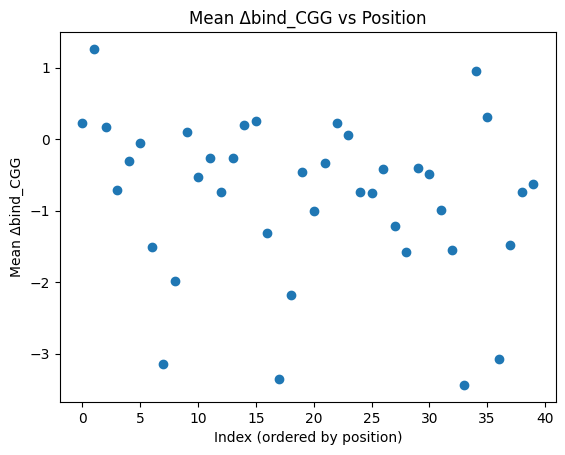

-0.7968246924246601
1.090970420802467


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Group by position, take the first wildtype amino acid for each position
wt_seq = (
    df.groupby("position")["wildtype"]
      .first()
      .sort_index()
      .str.cat()
)
print('len',len(wt_seq))

print(wt_seq)

df = df[df["single_nt"].apply(lambda x: isinstance(x, bool))]
df = df[df["single_nt"]]  # keep only single-nt rows
df['position'] = df['position'] - 1

# Group and compute mean/std
stats = df.groupby(["position", "annotation"])["delta_bind_CGG"].agg(["mean", "std"]).reset_index()

# Arrays (ordered by position)
positions = stats["position"].to_numpy()
mu_arr = stats["mean"].to_numpy() * np.log(10)
sigma_arr = stats["std"].to_numpy() * np.log(10)

print(len(positions))
print(mu_arr)
print(sigma_arr)

# Save CSV
stats_out = stats.copy()
stats_out["mean"] = stats_out["mean"] * np.log(10)
stats_out["std"] = stats_out["std"] * np.log(10)
stats_out.to_csv("annotation_position_mean_std.csv", index=False)

# Plot
plt.scatter(np.arange(len(mu_arr)), mu_arr)
plt.xlabel("Index (ordered by position)")
plt.ylabel("Mean Δbind_CGG")
plt.title("Mean Δbind_CGG vs Position")
plt.show()

print(np.mean(mu_arr))
print(np.std(mu_arr))

In [28]:
positions

array([ 25,  26,  27,  28,  29,  30,  31,  32,  49,  50,  51,  52,  53,
        54,  55,  56,  95,  96,  97,  98,  99, 100, 153, 154, 155, 156,
       157, 158, 176, 177, 178, 215, 216, 217, 218, 219, 220, 221, 222,
       223], dtype=int64)

In [29]:
print(df.annotation.unique())
# Keep only unique (position, annotation) pairs
pos_annotation_dict = (
    df.drop_duplicates(subset=["position", "annotation"])
      .set_index("position")["annotation"]
      .to_dict()
)

print(pos_annotation_dict)
cdr_positions = (
    df[df["annotation"].str.contains("CDR", na=False)]
    .drop_duplicates(subset=["position"])
    [["position"]]
    .to_records(index=False)
    .tolist()
)
cdr_positions=[pos[0] for pos in cdr_positions]
print(cdr_positions)#absolute position
#i need index of cdr_positions inside position array
cdr_positions_relative = [np.where(positions == p)[0][0] for p in cdr_positions]

print(cdr_positions_relative)

['CDRH1' 'CDRH2' 'CDRH3' 'CDRL1' 'CDRL2' 'CDRL3']
{25: 'CDRH1', 26: 'CDRH1', 27: 'CDRH1', 28: 'CDRH1', 29: 'CDRH1', 30: 'CDRH1', 31: 'CDRH1', 32: 'CDRH1', 49: 'CDRH2', 50: 'CDRH2', 51: 'CDRH2', 52: 'CDRH2', 53: 'CDRH2', 54: 'CDRH2', 55: 'CDRH2', 56: 'CDRH2', 95: 'CDRH3', 96: 'CDRH3', 97: 'CDRH3', 98: 'CDRH3', 99: 'CDRH3', 100: 'CDRH3', 153: 'CDRL1', 154: 'CDRL1', 155: 'CDRL1', 156: 'CDRL1', 157: 'CDRL1', 158: 'CDRL1', 176: 'CDRL2', 177: 'CDRL2', 178: 'CDRL2', 215: 'CDRL3', 216: 'CDRL3', 217: 'CDRL3', 218: 'CDRL3', 219: 'CDRL3', 220: 'CDRL3', 221: 'CDRL3', 222: 'CDRL3', 223: 'CDRL3'}
[25, 26, 27, 28, 29, 30, 31, 32, 49, 50, 51, 52, 53, 54, 55, 56, 95, 96, 97, 98, 99, 100, 153, 154, 155, 156, 157, 158, 176, 177, 178, 215, 216, 217, 218, 219, 220, 221, 222, 223]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


In [30]:
len(mu_arr)

40

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load and Process Experimental Data (from original code, unchanged) ---
# NOTE: Assume 'simulate_gc_history', T, S_mat, N_i, N_max, C_schedule, mu_arr,
# sigma_arr, and cdr_positions_relative are defined elsewhere in the context.
S_mat = np.array([[1] for pos in range (len(positions))])

N_h   = S_mat.shape[0]
print('Nh', N_h)
# Antigen concentration (constant here)
def C_schedule():
    return np.array([c])

Nh 40


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Simulation Parameters (PLACEHOLDERS: Replace with your actual context variables) ---
# NOTE: The following variables must be defined in your environment:
# T, S_mat, N_i, N_max, C_schedule, mu_arr, sigma_arr, cdr_positions_relative, 
# simulate_gc_history, positions 

N_SEEDS = 10 

# --- 2. Load and Process Experimental Data ---
df_mat = (pd.read_csv("../data_mat/data.csv", keep_default_na=False)
         [["time (days)", "delta_bind_CGG"]]
         .rename(columns={"time (days)": "t", "delta_bind_CGG": "x"}))

df_mat["t"] = df_mat["t"] * 2.0         # days -> 12h
df_mat["x"] = df_mat["x"] * np.log(10.0)  # log scale

times_exp = np.sort(df_mat.t.unique())
exp_mean = (df_mat.groupby("t")["x"]
                .mean()
                .reindex(times_exp)
                .values)
exp_std = (df_mat.groupby("t")["x"].std()
               .reindex(times_exp)
               .fillna(0.0)
               .values)


# --- 3. Run Multiple Simulations and Collect Results ---

# List to store mean total affinity (sum(h_i)) for each simulation round (Shape: (10, T+1))
all_sim_mean_sum_hi = [] 
# List to store mean h_i per position for each simulation (Shape: (10, T+1, N_h))
all_sim_mean_hi_per_time = [] 

for seed in range(N_SEEDS):
    # Run the simulation (PLACEHOLDER for function call)
    history, _, _ = simulate_gc_history(
        rounds        = T,
        S_mat         = S_mat,
        N_init        = N_i,
        N_max         = N_max,
        C_schedule    = C_schedule,
        mu_M          = mu_arr,
        sigma_M       = sigma_arr,
        mutable_positions=cdr_positions_relative,
        seed          = seed + 1
    )

    N_h = history[0].shape[1]
    
    # Trackers for the current simulation
    current_sim_mean_sum_hi = []
    mean_hi_per_time_single_sim = np.zeros((len(history), N_h))

    for t, pop in enumerate(history):
        if pop.size == 0:
            # Handle empty population for both metrics
            current_sim_mean_sum_hi.append(np.nan)
            mean_hi_per_time_single_sim[t, :] = np.nan
        else:
            # === KEY MODIFICATION ===
            # Fill NaNs with 0.0 to treat unmutated positions as 0 affinity contribution
            # This ensures we calculate the mean over the *entire* population
            pop_filled = np.nan_to_num(pop, nan=0.0)

            # 1. Total Affinity (sum(h_i)) tracking: Mean of the sum over population
            sum_hi_per_cell = pop_filled.sum(axis=1) 
            current_sim_mean_sum_hi.append(sum_hi_per_cell.mean())
            
            # 2. Individual h_i tracking: Mean h_i per position over population
            mean_hi_per_time_single_sim[t, :] = pop_filled.mean(axis=0)

    all_sim_mean_sum_hi.append(current_sim_mean_sum_hi)
    all_sim_mean_hi_per_time.append(mean_hi_per_time_single_sim)
    
    print(f"Simulation with seed={seed + 1} completed.")

# --- 4. Aggregate and Plot Total Affinity (sum(h_i)) ---

# Convert list of lists to a NumPy array for aggregation
sim_sum_hi_array = np.array(all_sim_mean_sum_hi) 

# Calculate the mean and standard deviation across the 10 simulations for plotting
sim_mean_agg = np.nanmean(sim_sum_hi_array, axis=0) 
sim_std_agg = np.nanstd(sim_sum_hi_array, axis=0) 

times = np.arange(len(history))

print("\nTotal Affinity Tracking (sum(h_i))")
print(f"Aggregated Mean: {sim_mean_agg}")
print(f"Aggregated STD: {sim_std_agg}")



Simulation with seed=1 completed.
Simulation with seed=2 completed.
Simulation with seed=3 completed.
Simulation with seed=4 completed.
Simulation with seed=5 completed.
Simulation with seed=6 completed.
Simulation with seed=7 completed.
Simulation with seed=8 completed.
Simulation with seed=9 completed.
Simulation with seed=10 completed.

Total Affinity Tracking (sum(h_i))
Aggregated Mean: [-2.80759706e-06 -1.19873993e-06  3.33923816e-03  7.83027052e-03
  1.95204887e-02  3.05863207e-02  4.49848249e-02  6.47422103e-02
  8.44898777e-02  1.12787967e-01  1.43222332e-01  1.74526673e-01
  2.13629603e-01  2.53464484e-01  3.02558411e-01  3.62702837e-01
  4.29524266e-01  5.09183952e-01  5.88784206e-01  6.80189499e-01
  7.85235144e-01  9.03548080e-01  1.03215164e+00  1.16185776e+00
  1.29242432e+00  1.43720198e+00  1.57263781e+00  1.70254760e+00
  1.82912527e+00  1.94411529e+00  2.05485615e+00  2.15701679e+00
  2.26460498e+00  2.35393417e+00  2.44087162e+00  2.52672613e+00
  2.59984866e+00  2.6

<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
C:\Users\maria\AppData\Local\Temp\ipykernel_7852\3448709175.py:9: SyntaxWarning: invalid escape sequence '\p'
  label="$\pm$1 STD (across 10 seeds)"


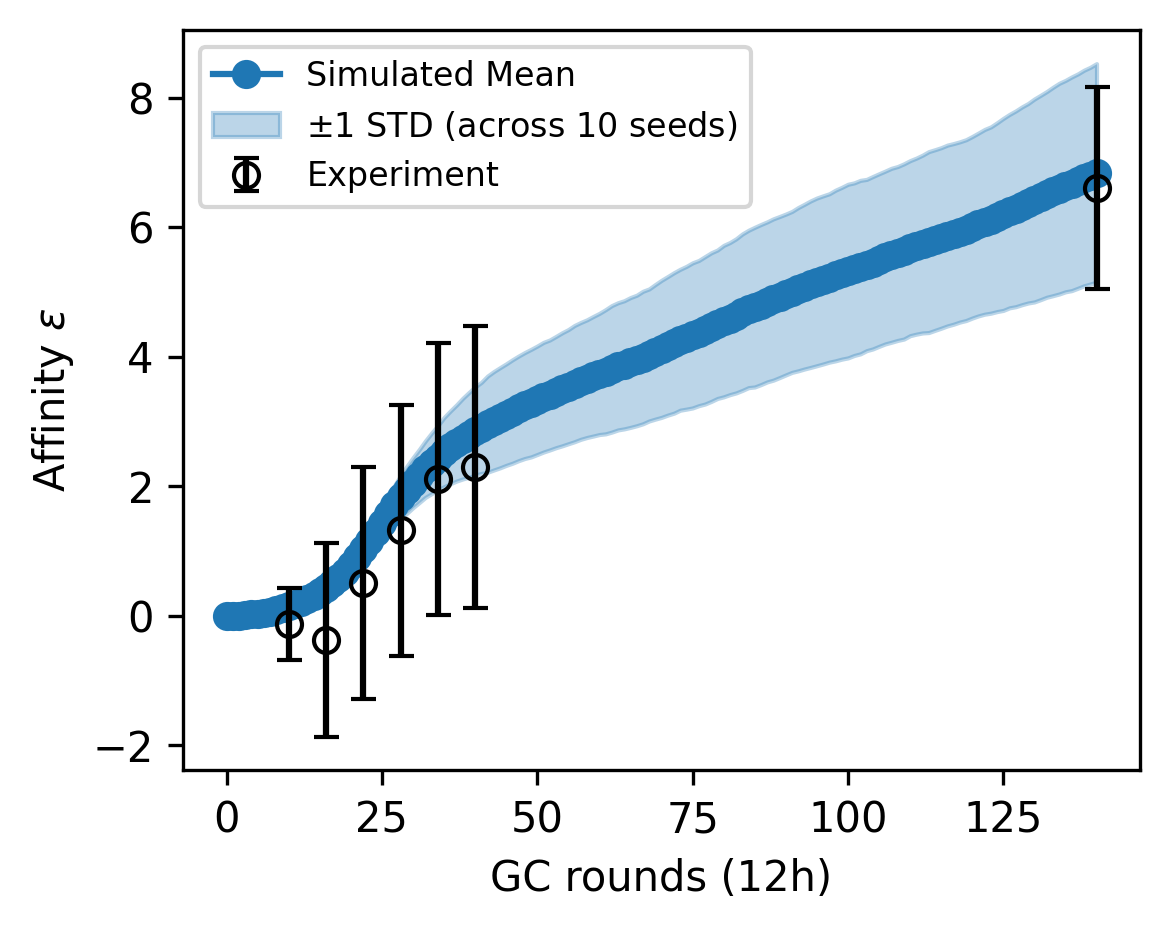

In [42]:
plt.figure(figsize=(4, 3.2), dpi=300)
plt.plot(times, sim_mean_agg, marker='o', color='C0', label="Simulated Mean")
plt.fill_between(
    times,
    sim_mean_agg - sim_std_agg,
    sim_mean_agg + sim_std_agg,
    color='C0',
    alpha=0.3,
    label="$\pm$1 STD (across 10 seeds)"
)

# Plot the experimental data
plt.errorbar(times_exp, exp_mean, yerr=exp_std,
             fmt='o', mfc='none', ecolor='k', color='k',
             capsize=3, label='Experiment')

plt.xlabel("GC rounds (12h)")
plt.ylabel(r"Affinity $\epsilon$")
# plt.title("Model affinity maturation (10 Replicates)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [34]:
# --- 5. Aggregate and Save Individual h_i (All Positions) ---

# Convert the list of (T+1, N_h) arrays into a single NumPy array
# Shape: (N_SEEDS, N_times, N_h)
sim_hi_array = np.array(all_sim_mean_hi_per_time) 

# Calculate the final mean h_i averaged over the 10 simulation seeds (axis=0)
# Shape: (N_times, N_h)
mean_hi_per_time_avg = np.nanmean(sim_hi_array, axis=0)

# Define times of interest (in 12h rounds)
times_of_interest = np.array([5, 8, 11, 14, 17, 20, 70]) * 2

# Get total number of positions
N_h = mean_hi_per_time_avg.shape[1]

# Build a DataFrame using the *averaged* mean h_i values for ALL positions
records = []

# Iterate through ALL positions (no filtering)
for i in range(N_h):
    position_label = positions[i] # Uses 'positions' list from your environment
    
    for t in times_of_interest:
        # Ensure we don't access out-of-bounds time indices
        if t < len(mean_hi_per_time_avg):
            records.append({
                "position": position_label,
                "time": t,
                "mean_hi": mean_hi_per_time_avg[t, i]
            })

df_out = pd.DataFrame(records)

# Save to CSV
df_out.to_csv("mean_hi_stochastic.csv", index=False)
print(f"\nSaved mean h_i values (averaged over {N_SEEDS} simulations) for {len(records)} entries to mean_hi_stochastic.csv")


Saved mean h_i values (averaged over 10 simulations) for 280 entries to mean_hi_stochastic.csv


# One round

In [35]:
# Turn your scalar params into per-site vectors (or set site-specific values here)
S_mat = np.array([[1] for pos in range (len(positions))])

N_h   = S_mat.shape[0]
print('Nh', N_h)
# Antigen concentration (constant here)
def C_schedule():
    return np.array([c])

history,parent_links, uniq_counts_hist  = simulate_gc_history(
    rounds      = T,
    S_mat       = S_mat,
    N_init      = N_i,
    N_max       = N_max,
    C_schedule  = C_schedule,
    mu_M        = mu_arr,
    sigma_M     = sigma_arr,
    mutable_positions=cdr_positions_relative,
    seed        = 1
)

print(f"Rounds simulated: {len(history)-1}")
for t, pop in enumerate(history):
    print(f"t={t:02d}  cycling cells={pop.shape[0]}")


Nh 40
Rounds simulated: 140
t=00  cycling cells=2500
t=01  cycling cells=2500
t=02  cycling cells=2500
t=03  cycling cells=2500
t=04  cycling cells=2500
t=05  cycling cells=2500
t=06  cycling cells=2500
t=07  cycling cells=2500
t=08  cycling cells=2500
t=09  cycling cells=2500
t=10  cycling cells=2500
t=11  cycling cells=2500
t=12  cycling cells=2500
t=13  cycling cells=2500
t=14  cycling cells=2500
t=15  cycling cells=2500
t=16  cycling cells=2500
t=17  cycling cells=2500
t=18  cycling cells=2500
t=19  cycling cells=2500
t=20  cycling cells=2500
t=21  cycling cells=2500
t=22  cycling cells=2500
t=23  cycling cells=2500
t=24  cycling cells=2500
t=25  cycling cells=2500
t=26  cycling cells=2500
t=27  cycling cells=2500
t=28  cycling cells=2500
t=29  cycling cells=2500
t=30  cycling cells=2500
t=31  cycling cells=2500
t=32  cycling cells=2500
t=33  cycling cells=2500
t=34  cycling cells=2500
t=35  cycling cells=2500
t=36  cycling cells=2500
t=37  cycling cells=2500
t=38  cycling cells=25

mean_exp [-0.12944443 -0.37343535  0.50442515  1.31840739  2.11250799  2.29889219
  6.60429562]
times_exp [ 10.  16.  22.  28.  34.  40. 140.]


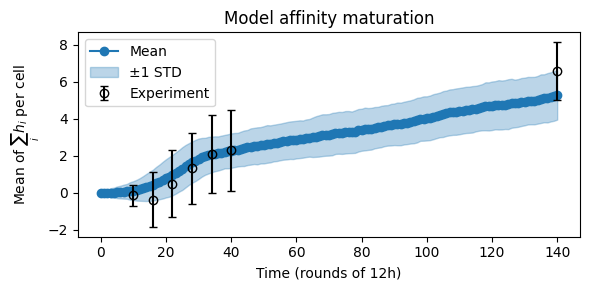

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# history is a list of arrays: one array per time point, shape (n_cells_t, N_h)
df_mat = (pd.read_csv("../data_mat/data.csv", keep_default_na=False)
        [["time (days)", "delta_bind_CGG"]]
        .rename(columns={"time (days)": "t", "delta_bind_CGG": "x"}))

df_mat["t"] = df_mat["t"] * 2.0            # days  →  12 h
df_mat["x"] = df_mat["x"] * np.log(10.0)   # log scale

times_exp = np.sort(df_mat.t.unique())
mean_exp  = (df_mat.groupby("t")["x"]
               .mean()
               .reindex(times_exp)
               .values)

print("mean_exp", mean_exp)
print("times_exp", times_exp)  # in 12 h
exp_mean  = mean_exp
exp_std   = (df_mat.groupby("t")["x"].std()
               .reindex(times_exp)
               .fillna(0.0)          # if only one replica at a time point
               .values)

mean_sum_hi_per_time = []
std_sum_hi_per_time = []

for pop in history:
    if pop.size == 0:
        mean_sum_hi_per_time.append(np.nan)
        std_sum_hi_per_time.append(np.nan)
    else:
        sum_hi_per_cell = pop.sum(axis=1)  # sum over h_i for each cell
        mean_sum_hi_per_time.append(sum_hi_per_cell.mean())
        std_sum_hi_per_time.append(sum_hi_per_cell.std())

times = np.arange(len(history))
mean_sum_hi_per_time = np.array(mean_sum_hi_per_time)
std_sum_hi_per_time = np.array(std_sum_hi_per_time)

plt.figure(figsize=(6, 3))
plt.plot(times, mean_sum_hi_per_time, marker='o', color='C0', label="Mean")
plt.fill_between(
    times,
    mean_sum_hi_per_time - std_sum_hi_per_time,
    mean_sum_hi_per_time + std_sum_hi_per_time,
    color='C0',
    alpha=0.3,
    label="±1 STD"
)
plt.errorbar(times_exp, exp_mean, yerr=exp_std,
             fmt='o', mfc='none', ecolor='k', color='k',
             capsize=3, label='Experiment')
plt.xlabel("Time (rounds of 12h)")
plt.ylabel(r"Mean of $\sum_i h_i$ per cell")
plt.title("Model affinity maturation")
plt.legend()
plt.tight_layout()
plt.show()


# Nb of mutations

(<Figure size 337.5x210 with 1 Axes>,
 <Axes: title={'center': 'Average unique mutated sites vs generation'}, xlabel='Generation', ylabel='Avg. unique mutated sites'>)

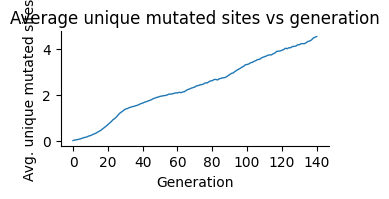

In [37]:
# Global average across all GC cells per generation
def avg_unique_mutations_per_generation(uniq_counts_hist):
    import numpy as np
    return np.array([uc.mean() if uc.size else 0.0 for uc in uniq_counts_hist], dtype=float)
def avg_unique_mutations_in_subtree(uniq_counts_hist, node_indices):
    import numpy as np
    return np.array([
        uniq_counts_hist[t][node_indices[t]].mean() if len(node_indices[t]) else 0.0
        for t in range(len(node_indices))
    ], dtype=float)
def plot_avg_unique_mutations(avg_vals, title=None, figsize=(3.375, 2.1)):
    import numpy as np, matplotlib.pyplot as plt
    T = len(avg_vals) - 1
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(np.arange(T+1), avg_vals, lw=1.0)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Avg. unique mutated sites")
    ax.set_xticks(np.arange(0, T+1, 20))
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.grid(False)
    if title:
        ax.set_title(title, pad=6)
    plt.tight_layout()
    return fig, ax

# Average across all GC cells
avg_all = avg_unique_mutations_per_generation(uniq_counts_hist)
plot_avg_unique_mutations(avg_all, title="Average unique mutated sites vs generation")




In [38]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Validation & ancestry
# =========================

def validate_tree(history, parent_links):
    T = len(history) - 1
    if T < 1:
        raise ValueError("Need at least two generations 0..T.")
    if len(parent_links) != len(history):
        raise ValueError("parent_links must have same length as history.")
    for t in range(1, T+1):
        if parent_links[t].shape[0] != history[t].shape[0]:
            raise ValueError(f"parent_links[{t}] length must match history[{t}] rows.")
        n_prev = history[t-1].shape[0]
        p = parent_links[t]
        if p.size and ((p < 0).any() or (p >= n_prev).any()):
            raise ValueError(f"parent_links[{t}] has invalid indices.")
    return T

def ancestry_path(parent_links, final_row_T):
    """Row index of the cell at each generation on the chosen lineage."""
    T = len(parent_links) - 1
    path = [None]*(T+1)
    path[T] = int(final_row_T)
    for t in range(T, 0, -1):
        path[t-1] = int(parent_links[t][path[t]])
    return path  # list of ints, len T+1

# =========================
# Subtree construction
# =========================

def build_subtree_from_founder(parent_links, founder_row0):
    """
    Collect all descendants of the founder (gen 0, row founder_row0) down to T.
    Returns:
      node_indices[t]: absolute row indices in history[t] belonging to the subtree.
    """
    T = len(parent_links) - 1
    node_indices = [np.array([], dtype=int) for _ in range(T+1)]
    node_indices[0] = np.array([int(founder_row0)], dtype=int)

    for t in range(1, T+1):
        parents_t = parent_links[t]  # parent row in gen t-1 for each node in gen t
        if node_indices[t-1].size:
            mask = np.isin(parents_t, node_indices[t-1])
            node_indices[t] = np.flatnonzero(mask).astype(int)
        else:
            node_indices[t] = np.array([], dtype=int)
    return node_indices

def prune_subtree_to_reach_T(parent_links, node_indices):
    """
    Prune away branches that don't lead to any node at generation T.
    Keeps only nodes that have a path to gen T (the 'last step').
    """
    T = len(node_indices) - 1
    if node_indices[T].size == 0:
        # nothing reaches T; return empty
        return [np.array([], dtype=int) for _ in range(T+1)]

    # Build quick child lookup (by absolute row ids)
    # children_rows[t][row_parent] = list of child rows in gen t+1
    children_rows = [dict() for _ in range(T)]
    for t in range(T):
        parents_next = parent_links[t+1]
        rows_t = set(int(r) for r in node_indices[t])
        rows_tp1 = node_indices[t+1]
        # initialize dict for nodes present at t
        for r in rows_t:
            children_rows[t][r] = []
        # populate edges restricted to current subtree
        for row_child in rows_tp1:
            p = int(parents_next[row_child])
            if p in children_rows[t]:
                children_rows[t][p].append(int(row_child))

    # Backward keep-sets
    keep = [set() for _ in range(T+1)]
    keep[T] = set(int(r) for r in node_indices[T])  # everything at T is kept

    for t in range(T-1, -1, -1):
        for r in node_indices[t]:
            r_int = int(r)
            # keep parent if any child is kept at next layer
            if any((c in keep[t+1]) for c in children_rows[t].get(r_int, [])):
                keep[t].add(r_int)

    # Filter node_indices
    pruned = [np.array(sorted(list(keep[t])), dtype=int) for t in range(T+1)]
    return pruned

# =========================
# Plot: time vs sum(h) with links
# =========================

def plot_subtree_time_vs_sum(history, parent_links, node_indices,
                             title=None, figsize=(5.0, 4.2),
                             marker_size=2, line_width=0.8):
    """
    x-axis: generation (time)
    y-axis: sum_i h_i
    Points: colored by sum_i h_i
    Edges: parent -> child links, using the parent's color
    """
    import numpy as np
    import matplotlib.pyplot as plt

    T = len(node_indices) - 1

    # --- Precompute sums per node in subtree ---
    sums = []
    for t, inds in enumerate(node_indices):
        if inds.size:
            sums.append(np.sum(history[t][inds], axis=1).astype(float))
        else:
            sums.append(np.array([], dtype=float))

    # --- Global color scaling (robust) ---
    # cmap = plt.get_cmap()
    if any(v.size for v in sums):
        all_vals = np.concatenate([v for v in sums if v.size])
        if all_vals.size > 1:
            vmin = float(np.percentile(all_vals, 1.0))
            vmax = float(np.percentile(all_vals, 99.0))
            if vmax <= vmin:
                vmax = vmin + 1e-9
        else:
            vmin = vmax = float(all_vals[0])
    else:
        vmin = vmax = 0.0

#to_colo

    # --- Map row id -> rank within layer (for fast lookup) ---
    ranks = []
    for t, inds in enumerate(node_indices):
        ranks.append({int(r): k for k, r in enumerate(inds)})

    # --- Build edges (with parent's color) ---
    edges = []
    edge_colors = []
    for t in range(T):  # edges from t -> t+1
        if node_indices[t].size == 0 or node_indices[t+1].size == 0:
            continue
        parents_next = parent_links[t+1]
        for k_child, row_child in enumerate(node_indices[t+1]):
            p_row = int(parents_next[row_child])
            if p_row in ranks[t]:
                k_parent = ranks[t][p_row]
                x0, y0 = t,   float(sums[t][k_parent])
                x1, y1 = t+1, float(sums[t+1][k_child])
                edges.append(((x0, y0), (x1, y1)))
                edge_colors.append(to_color(y0))  # parent's color

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    # edges first (colored by parent)
    for ((x0, y0), (x1, y1)), col in zip(edges, edge_colors):
        ax.plot([x0, x1], [y0, y1], lw=line_width, alpha=0.9, color=col)

    # nodes (colored by their own sum_i h_i)
  

    # aesthetics
    ax.set_xlabel("GC rounds (12h)")
    ax.set_ylabel("Affinity (-E(h))")
    # tick every 20 generations
    if T >= 0:
        ax.set_xticks(np.arange(0, T+1, 20 if T >= 20 else max(1, T)))
    # for spine in ["top", "right"]:
    #     ax.spines[spine].set_visible(False)
    ax.grid(False)
    # if title:
    #     ax.set_title(title, pad=6)

    # optional colorbar if we drew points
    # if last_scatter is not None:
    #     cb = fig.colorbar(last_scatter, ax=ax, fraction=0.05, pad=0.02)
    #     cb.set_label(r"$-E(h)$", rotation=90)

    plt.tight_layout()
    return fig, ax


# =========================
# Driver
# =========================

def plot_founder_subtree_for_final_cell(history, parent_links, final_row_T,
                                        require_reach_T=True,
                                        show_lineage_plot=False,
                                        title_subtree="Founder subtree (time vs sum h)"):
    """
    1) Validate and get ancestry of a chosen final cell.
    2) Use its founder at gen 0 as the subtree root.
    3) Build full descendant subtree; optionally prune branches that don't reach T.
    4) Plot subtree with time on x and sum(h) on y, with links.
    """
    T = validate_tree(history, parent_links)
    path = ancestry_path(parent_links, final_row_T)  # rows at 0..T for this lineage
    founder_row0 = path[0]

    # full subtree from founder
    nodes = build_subtree_from_founder(parent_links, founder_row0)

    # prune to branches that reach T if requested
    if require_reach_T:
        nodes = prune_subtree_to_reach_T(parent_links, nodes)

    fig_sub, ax_sub = plot_subtree_time_vs_sum(
        history, parent_links, nodes, title=title_subtree
    )

    fig_lin, ax_lin = None, None
    if show_lineage_plot:
        traj = np.vstack([history[t][path[t]] for t in range(T+1)])
        y = traj.sum(axis=1)
        fig_lin, ax_lin = plt.subplots(figsize=(5.0, 2.6))
        ax_lin.plot(np.arange(T+1), y, lw=1.5)
        ax_lin.set_xlabel("Generation")
        ax_lin.set_ylabel(r"Lineage $\sum_i h_i$")
        for spine in ["top", "right"]:
            ax_lin.spines[spine].set_visible(False)
        ax_lin.grid(False)
        plt.tight_layout()

    return {
        "path_rows": path,
        "subtree_node_indices": nodes,
        "fig_subtree": fig_sub,
        "ax_subtree": ax_sub,
        "fig_lineage": fig_lin,
        "ax_lineage": ax_lin
    }

# -------- Example --------



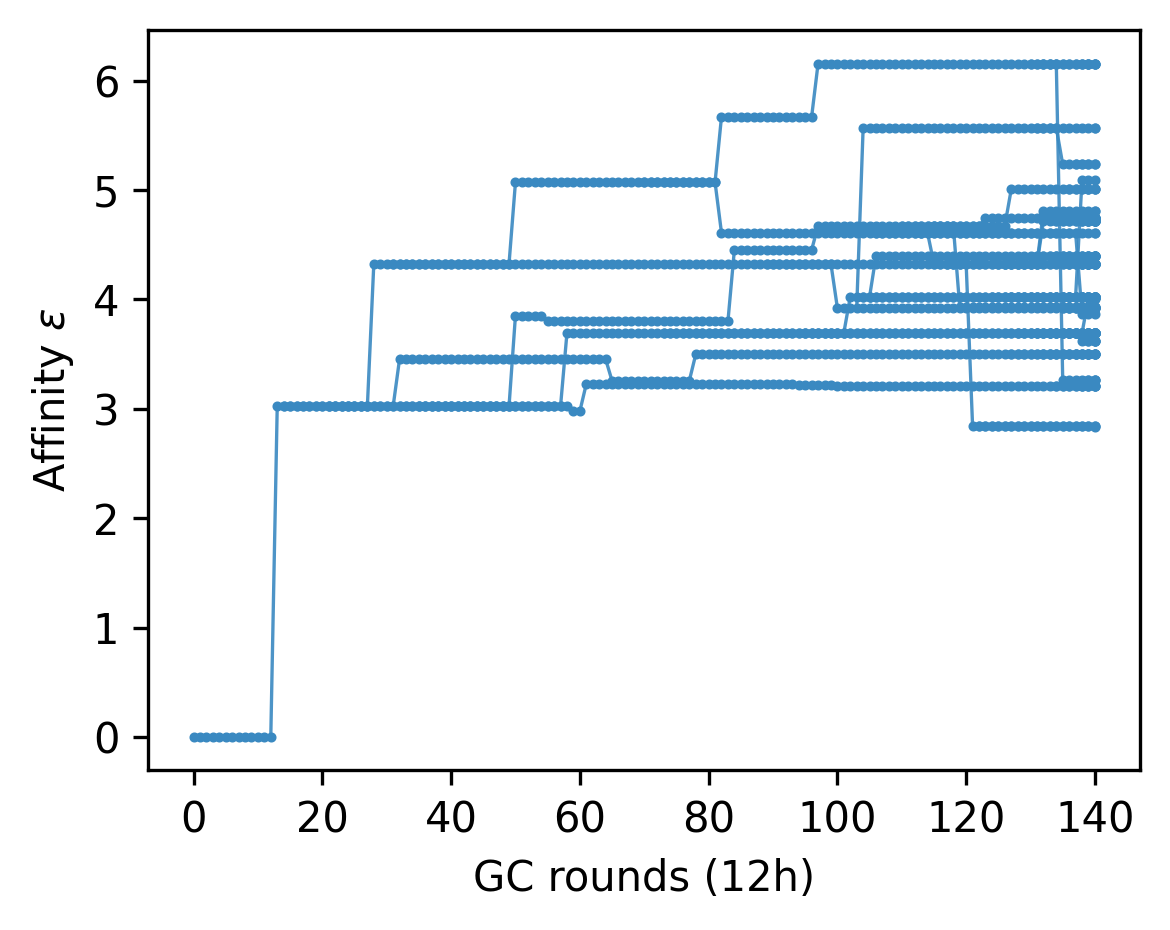

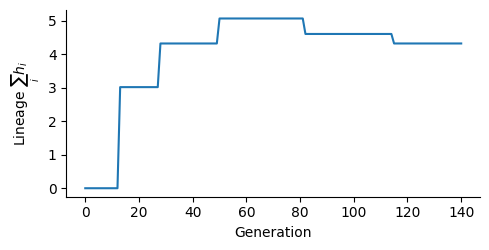

In [41]:
def plot_subtree_time_vs_sum(history, parent_links, node_indices,
                             title=None, figsize=(4.0, 3.2),
                             marker_size=2, line_width=0.8):
    """
    x-axis: generation (time)
    y-axis: sum_i h_i
    Points: Blue
    Edges: Blue
    """
    import numpy as np
    import matplotlib.pyplot as plt

    T = len(node_indices) - 1

    # --- Precompute sums per node in subtree ---
    sums = []
    for t, inds in enumerate(node_indices):
        if inds.size:
            sums.append(np.sum(history[t][inds], axis=1).astype(float))
        else:
            sums.append(np.array([], dtype=float))

    # --- Simplified Color Function (Always Blue) ---
    def to_color(val):
        return "#3a89c1"  # Or use hex like "#1f77b4"

    # --- Map row id -> rank within layer (for fast lookup) ---
    ranks = []
    for t, inds in enumerate(node_indices):
        ranks.append({int(r): k for k, r in enumerate(inds)})

    # --- Build edges ---
    edges = []
    edge_colors = []
    for t in range(T):  # edges from t -> t+1
        if node_indices[t].size == 0 or node_indices[t+1].size == 0:
            continue
        parents_next = parent_links[t+1]
        for k_child, row_child in enumerate(node_indices[t+1]):
            p_row = int(parents_next[row_child])
            if p_row in ranks[t]:
                k_parent = ranks[t][p_row]
                x0, y0 = t,   float(sums[t][k_parent])
                x1, y1 = t+1, float(sums[t+1][k_child])
                edges.append(((x0, y0), (x1, y1)))
                edge_colors.append(to_color(y0))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    # edges first
    for ((x0, y0), (x1, y1)), col in zip(edges, edge_colors):
        ax.plot([x0, x1], [y0, y1], lw=line_width, alpha=0.9, color=col)

    # nodes (colored blue manually)
    for t in range(T+1):
        if node_indices[t].size:
            xs = np.full(node_indices[t].size, t, dtype=float)
            # Removed cmap, vmin, vmax. Set c="blue".
            ax.scatter(xs, sums[t], s=marker_size, zorder=3, c="#3a89c1")

    # aesthetics
    ax.set_xlabel("GC rounds (12h)")
    ax.set_ylabel(r"Affinity $\epsilon$")
    
    if T >= 0:
        ax.set_xticks(np.arange(0, T+1, 20 if T >= 20 else max(1, T)))
    
    ax.grid(False)
    # if title:
    #     ax.set_title(title, pad=6)

    # Colorbar removed as it is no longer relevant
    
    plt.tight_layout()
    return fig, ax

final_row_T = 7
out = plot_founder_subtree_for_final_cell(history, parent_links, final_row_T,
                                          require_reach_T=True,
                                          show_lineage_plot=True)

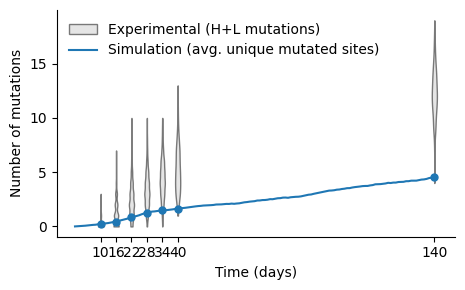

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Load data ---
data_csv_path = "../data_mat/data.csv"
df_mat2 = pd.read_csv(
    data_csv_path,
    keep_default_na=False
)[["time (days)", "mouse", "delta_bind_CGG", "mutations_H", "mutations_L",
   "n_mutations_H", "n_mutations_L"]]
df_mat2["time (days)"] = df_mat2["time (days)"] * 2

# --- Compute combined mutations ---
df_mat2["n_mutations_total"] = df_mat2["n_mutations_H"] + df_mat2["n_mutations_L"]

# --- Figure ---
fig, ax = plt.subplots(figsize=(4.75, 3.0))

# Unique experimental times (sorted)
times_sorted = np.sort(df_mat2["time (days)"].unique())

# --- Violin plot for experimental data ---
parts = ax.violinplot(
    [df_mat2.loc[df_mat2["time (days)"] == t, "n_mutations_total"] for t in times_sorted],
    positions=times_sorted,
    widths=2.0,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for pc in parts['bodies']:
    pc.set_facecolor('#cccccc')
    pc.set_edgecolor('black')
    pc.set_alpha(0.5)

violin_patch = Patch(facecolor='#cccccc', edgecolor='black', alpha=0.5,
                     label="Experimental (H+L mutations)")

# --- Simulation overlay ---
# 1) plot value for all T (continuous line, no dots)
#    Assumes avg_all is an array-like with one value per integer time step (day after scaling).
x_sim = np.arange(len(avg_all))
line_sim, = ax.plot(x_sim, avg_all, lw=1.5, color='tab:blue',
                    label="Simulation (avg. unique mutated sites)")

# 2) show simulation *only at experimental times* as markers (no connecting lines)
y_at_exp_times = [avg_all[int(t)] for t in times_sorted]
ax.scatter(times_sorted, y_at_exp_times, s=25, color='tab:blue', zorder=3)

# --- Aesthetics ---
ax.set_xlabel("Time (days)")
ax.set_ylabel("Number of mutations")
ax.set_xticks(times_sorted)
ax.tick_params(axis='both', which='both', direction='out')
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.grid(False)

# Legend
ax.legend(handles=[violin_patch, line_sim], frameon=False)

plt.tight_layout()
plt.show()
